## Dataset IBM HR Attrition

In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

### Data Wrangling

In [2]:
# Load Dataset
ibm_df = pd.read_csv("Dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
ibm_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Data Dictionary
def generate_data_dictionary(df):
    dd = []
    for col in df.columns:
        dd.append({
            'Column': col,
            'Data Type': str(df[col].dtype),
            'Non-Null Count': df[col].notnull().sum(),
            'Null Count': df[col].isnull().sum(),
            'Unique Values': df[col].nunique(),
            'Sample Values': str(df[col].dropna().unique()[:3].tolist())
        })
    return pd.DataFrame(dd)

data_dict = generate_data_dictionary(ibm_df)
data_dict

,Column,Data Type,Non-Null Count,Null Count,Unique Values,Sample Values
0,Age,int64,1470,0,43,"[41, 49, 37]"
1,Attrition,object,1470,0,2,"['Yes', 'No']"
2,BusinessTravel,object,1470,0,3,"['Travel_Rarely', 'Travel_Frequently', 'Non-Tr..."
3,DailyRate,int64,1470,0,886,"[1102, 279, 1373]"
4,Department,object,1470,0,3,"['Sales', 'Research & Development', 'Human Res..."
5,DistanceFromHome,int64,1470,0,29,"[1, 8, 2]"
6,Education,int64,1470,0,5,"[2, 1, 4]"
7,EducationField,object,1470,0,6,"['Life Sciences', 'Other', 'Medical']"
8,EmployeeCount,int64,1470,0,1,[1]
9,EmployeeNumber,int64,1470,0,1470,"[1, 2, 4]"


In [4]:
# Data Dictionary - Description
manual_desc = {
    'Age':                      ('Integer',  'Usia karyawan',                                        '18–60'),
    'Attrition':                ('String',   'Status resign karyawan — TARGET VARIABLE',             'Yes / No'),
    'BusinessTravel':           ('String',   'Frekuensi perjalanan dinas',                           'Non-Travel, Travel_Rarely, Travel_Frequently'),
    'DailyRate':                ('Integer',  'Tarif harian karyawan',                                '100–1500'),
    'Department':               ('String',   'Departemen tempat bekerja',                            'Sales, R&D, HR'),
    'DistanceFromHome':         ('Integer',  'Jarak rumah ke kantor (km)',                           '1–29'),
    'Education':                ('Integer',  'Tingkat pendidikan (1=Below College, 5=Doctor)',        '1–5'),
    'EducationField':           ('String',   'Bidang pendidikan',                                    'Life Sciences, Medical, Marketing, ...'),
    'EmployeeCount':            ('Integer',  'Jumlah karyawan (konstan=1, tidak informatif)',         '1'),
    'EmployeeNumber':           ('Integer',  'ID unik karyawan',                                     '1–2068'),
    'EnvironmentSatisfaction':  ('Integer',  'Kepuasan terhadap lingkungan kerja (1=Low, 4=Very High)','1–4'),
    'Gender':                   ('String',   'Jenis kelamin karyawan',                               'Male / Female'),
    'HourlyRate':               ('Integer',  'Tarif per jam karyawan',                               '30–100'),
    'JobInvolvement':           ('Integer',  'Tingkat keterlibatan dalam pekerjaan (1=Low, 4=Very High)','1–4'),
    'JobLevel':                 ('Integer',  'Level jabatan karyawan',                               '1–5'),
    'JobRole':                  ('String',   'Posisi/jabatan karyawan',                              'Manager, Sales Exec, ...'),
    'JobSatisfaction':          ('Integer',  'Kepuasan terhadap pekerjaan (1=Low, 4=Very High)',      '1–4'),
    'MaritalStatus':            ('String',   'Status pernikahan',                                    'Single, Married, Divorced'),
    'MonthlyIncome':            ('Integer',  'Gaji bulanan dalam USD',                               '1009–19999'),
    'MonthlyRate':              ('Integer',  'Tarif bulanan karyawan',                               '2094–26999'),
    'NumCompaniesWorked':       ('Integer',  'Jumlah perusahaan tempat bekerja sebelumnya',          '0–9'),
    'Over18':                   ('String',   'Apakah usia di atas 18 (konstan=Y, tidak informatif)', 'Y'),
    'OverTime':                 ('String',   'Apakah karyawan sering lembur',                        'Yes / No'),
    'PercentSalaryHike':        ('Integer',  'Persentase kenaikan gaji terakhir',                    '11–25%'),
    'PerformanceRating':        ('Integer',  'Rating performa (konstan 3–4, kurang variatif)',        '3–4'),
    'RelationshipSatisfaction': ('Integer',  'Kepuasan hubungan antar rekan kerja (1=Low, 4=Very High)','1–4'),
    'StandardHours':            ('Integer',  'Jam kerja standar (konstan=80, tidak informatif)',      '80'),
    'StockOptionLevel':         ('Integer',  'Level opsi saham yang dimiliki karyawan',              '0–3'),
    'TotalWorkingYears':        ('Integer',  'Total tahun pengalaman kerja',                         '0–40'),
    'TrainingTimesLastYear':    ('Integer',  'Jumlah pelatihan yang diikuti tahun lalu',             '0–6'),
    'WorkLifeBalance':          ('Integer',  'Keseimbangan kerja-kehidupan (1=Bad, 4=Best)',         '1–4'),
    'YearsAtCompany':           ('Integer',  'Lama bekerja di perusahaan ini (tahun)',               '0–40'),
    'YearsInCurrentRole':       ('Integer',  'Lama di jabatan saat ini (tahun)',                     '0–18'),
    'YearsSinceLastPromotion':  ('Integer',  'Tahun sejak promosi terakhir',                         '0–15'),
    'YearsWithCurrManager':     ('Integer',  'Lama bekerja dengan manajer saat ini (tahun)',         '0–17'),
}

dd_manual = pd.DataFrame([
    {'Column': col, 'Data Type': v[0], 'Description': v[1], 'Range / Values': v[2]}
    for col, v in manual_desc.items()
])

dd_manual

,Column,Data Type,Description,Range / Values
0,Age,Integer,Usia karyawan,18–60
1,Attrition,String,Status resign karyawan — TARGET VARIABLE,Yes / No
2,BusinessTravel,String,Frekuensi perjalanan dinas,"Non-Travel, Travel_Rarely, Travel_Frequently"
3,DailyRate,Integer,Tarif harian karyawan,100–1500
4,Department,String,Departemen tempat bekerja,"Sales, R&D, HR"
5,DistanceFromHome,Integer,Jarak rumah ke kantor (km),1–29
6,Education,Integer,"Tingkat pendidikan (1=Below College, 5=Doctor)",1–5
7,EducationField,String,Bidang pendidikan,"Life Sciences, Medical, Marketing, ..."
8,EmployeeCount,Integer,"Jumlah karyawan (konstan=1, tidak informatif)",1
9,EmployeeNumber,Integer,ID unik karyawan,1–2068


 - Penjelasan
 
Dataset IBM HR Attrition adalah kumpulan data yang berisi informasi tentang karyawan di perusahaan IBM, termasuk apakah mereka mengalami attrition (berhenti bekerja) atau tidak. Dataset ini sering digunakan untuk analisis dan prediksi terkait dengan faktor-faktor yang mempengaruhi keputusan karyawan untuk meninggalkan perusahaan.

In [5]:
ibm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# Mengecek nilai NULL
ibm_df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
# Duplikat data
print("Jumlah Duplikasi: ", ibm_df.duplicated().sum())

Jumlah Duplikasi:  0


In [8]:
ibm_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


- Analisa

Berdasarkan data wrangling diatas terlihat bahwwa dataset ini tidak memiliki nilai NaN maupun nilai duplikat, maka dari itu tidak perlu dilakukan pembersihan untuk nilai tersebut. Mungkin bisa ketahap data wrangling lanjutan yaitu mengecek Outlier dan Keseimbangan Data.

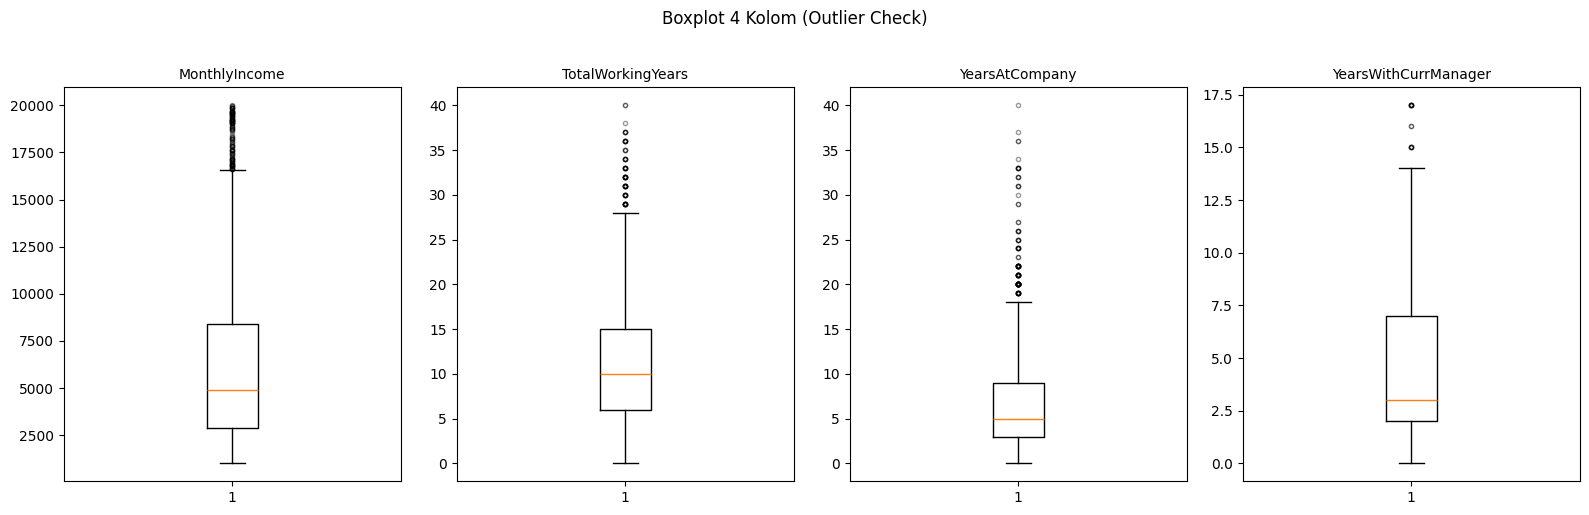

In [9]:
# Mengecek Outlier
cols = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsWithCurrManager']

fig, axes = plt.subplots(1, len(cols), figsize=(16, 5))

for ax, col in zip(axes, cols):
    ax.boxplot(
        ibm_df[col],
        showfliers=True,
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

plt.suptitle('Boxplot 4 Kolom (Outlier Check)', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Mengecek keseimbangan dataset
print(ibm_df['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


- Penjelasan

Pengecekan Outlier di 4 kolom tersebut dilakukan karena biasanya terdapat karyawan(manajer/eksekutif) yang mempunyai gaji diatas rata-rata dan sudah bekerja di perusahaan itu selama bertahun-tahun. Untuk keseimbangan dataset pada Attrition bisa terlihat lebih dominan 'No' dengan 84% sehingga diperlukan penyesuain saat sebelum melakukan pemodelan. 

### Explaratory Data Analysis

1. Pertanyaan Bisnis 1:

"Apakah karyawan yang melakukan OverTime memiliki persentase Attrition (resign) lebih tinggi dibandingkan karyawan yang tidak lembur dalam periode data saat ini?"

- Specific: Menentukan apakah karyawan yang memiliki status OverTime (lembur) menunjukkan kecenderungan untuk Attrition (resign) yang lebih tinggi dibandingkan yang tidak lembur.
- Measurable: Membuktikan secara statistik apakah tingkat attrition pada kelompok "OverTime: Yes" minimal 2 kali lipat lebih besar dibandingkan kelompok "OverTime: No".
- Action-oriented: Hasil analisis akan digunakan untuk merekomendasikan kebijakan pembatasan jam lembur atau peninjauan beban kerja tim yang memiliki tingkat lembur tertinggi.
- Relevant: Mengurangi turnover akibat kelelahan (burnout) adalah kunci untuk menjaga stabilitas operasional perusahaan.
- Time-bound: Analisis diselesaikan menggunakan data historis yang tersedia pada dataset saat ini untuk periode evaluasi tahun ini.

2. Pertanyaan Bisnis 2:

"Apakah karyawan dengan tingkat MonthlyIncome di bawah rata-rata namun memiliki TotalWorkingYears di atas 10 tahun memiliki korelasi signifikan terhadap kepuasan kerja (JobSatisfaction) yang rendah dan status Attrition 'Yes'?"

- Specific: Mengidentifikasi risiko resign pada kelompok karyawan "Loyal tapi Underpaid", yaitu mereka yang memiliki TotalWorkingYears > 10 tahun namun MonthlyIncome berada di bawah median (50%) perusahaan.
- Measurable: Menghitung perbandingan persentase Attrition antara kelompok tersebut dengan kelompok karyawan senior yang memiliki gaji di atas median.
- Action-oriented: Memberikan dasar data bagi departemen HR untuk melakukan salary adjustment (penyesuaian gaji) atau pemberian loyalty bonus khusus bagi karyawan senior yang rentan resign.
- Relevant: Menahan karyawan lama sangat penting karena mereka memiliki institutional knowledge (ilmu/pengalaman internal) yang sulit digantikan.
- Time-bound: Target hasil analisis ini tersedia sebelum periode tinjauan kompensasi dan manfaat (C&B) perusahaan berikutnya.

In [11]:
# Analisis pertanyaan bisnis
df = ibm_df.copy()

# Pertanyaan 1
overtime_analysis = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
print("--- Dampak Lembur (OverTime) Terhadap Resign (%) ---")
print(overtime_analysis.round(2))
print("\n")

--- Dampak Lembur (OverTime) Terhadap Resign (%) ---
Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53




In [12]:
# Pertanyaan 2
# Mencari titik tengah (median) untuk membagi data secara adil
median_income = df['MonthlyIncome'].median()
median_tenure = df['YearsAtCompany'].median()

# Membuat segmentasi / kohort
df['Segmentasi_Gaji'] = np.where(df['MonthlyIncome'] < median_income, 'Gaji Rendah', 'Gaji Tinggi')
df['Segmentasi_MasaKerja'] = np.where(df['YearsAtCompany'] >= median_tenure, 'Masa Kerja Lama', 'Masa Kerja Singkat')
df['Kohort'] = df['Segmentasi_Gaji'] + " & " + df['Segmentasi_MasaKerja']

# Menghitung persentase resign tiap kohort
cohort_analysis = df.groupby('Kohort')['Attrition'].value_counts(normalize=True).unstack() * 100
print(f"Median Gaji Bulanan: ${median_income}")
print(f"Median Masa Kerja: {median_tenure} tahun\n")
print("--- Analisis Kohort (Gaji + Masa Kerja) Terhadap Resign (%) ---")
print(cohort_analysis.round(2).sort_values(by='Yes', ascending=False))

Median Gaji Bulanan: $4919.0
Median Masa Kerja: 5.0 tahun

--- Analisis Kohort (Gaji + Masa Kerja) Terhadap Resign (%) ---
Attrition                            No    Yes
Kohort                                        
Gaji Rendah & Masa Kerja Singkat  71.15  28.85
Gaji Tinggi & Masa Kerja Singkat  86.55  13.45
Gaji Rendah & Masa Kerja Lama     87.12  12.88
Gaji Tinggi & Masa Kerja Lama     90.43   9.57


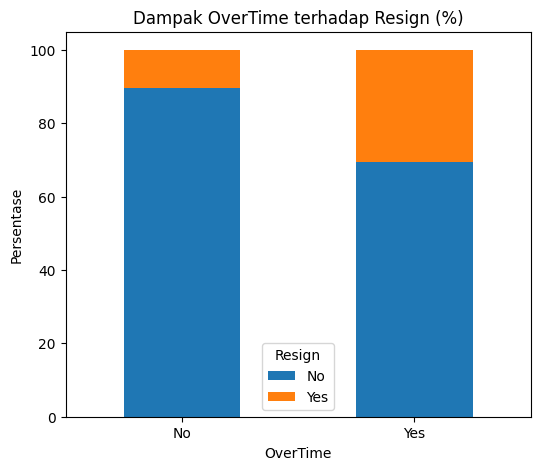

In [13]:
# Visualisasi Data

# Pertanyaan ke-1
overtime_analysis.plot(
    kind='bar',
    stacked=True,
    figsize=(6,5)
)

plt.title('Dampak OverTime terhadap Resign (%)')
plt.ylabel('Persentase')
plt.xlabel('OverTime')
plt.legend(title='Resign')
plt.xticks(rotation=0)
plt.show()

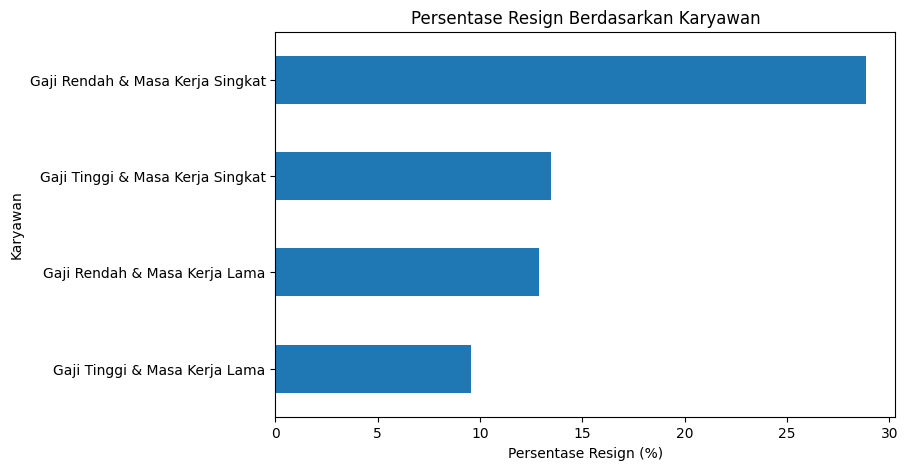

In [14]:
# Pertanyaan ke-2
cohort_analysis_sorted = cohort_analysis.sort_values(by='Yes', ascending=True)

cohort_analysis_sorted['Yes'].plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Persentase Resign Berdasarkan Karyawan')
plt.xlabel('Persentase Resign (%)')
plt.ylabel('Karyawan')
plt.show()

#### Penjelasan

* Jawaban dari pertanyaan bisnis 1

Karyawan yang sering mengalami lembur terlihat memiliki kecenderungan resign yang jauh lebih tinggi dibandingkan karyawan yang tidak lembur. Persentase resign pada kelompok yang lembur mencapai sekitar 30%, sedangkan pada kelompok tanpa lembur hanya sekitar 10%. Perbedaan ini menunjukkan bahwa beban kerja berlebih dapat menjadi salah satu faktor yang mendorong karyawan untuk meninggalkan perusahaan.

Hasil ini mengindikasikan bahwa kondisi kerja yang kurang seimbang, terutama terkait jam kerja tambahan, berpengaruh terhadap tingkat kenyamanan dan kepuasan kerja karyawan.

* untuk pertanyaan 2

Kelompok karyawan yang paling banyak memutuskan resign berasal dari karyawan baru dengan tingkat gaji rendah, dengan persentase sekitar 28%. Sementara itu, karyawan lama dengan gaji rendah memiliki tingkat resign yang lebih rendah, yaitu sekitar 13%.

Menariknya, karyawan baru dengan gaji tinggi juga tetap menunjukkan tingkat resign yang cukup besar, sekitar 14%, bahkan lebih tinggi dibandingkan karyawan lama dengan gaji rendah. Hal ini menunjukkan bahwa masa kerja yang singkat memiliki pengaruh yang cukup kuat terhadap keputusan resign, bahkan lebih dominan dibandingkan faktor gaji saja.

Temuan ini memperlihatkan bahwa proses adaptasi, kenyamanan kerja, dan ekspektasi di awal masa kerja kemungkinan turut memengaruhi keputusan karyawan untuk bertahan atau keluar dari perusahaan.

C:\Users\Nashril Fikri\AppData\Local\Temp\ipykernel_25816\3657063136.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='RelationshipSatisfaction', y='Attrition',
C:\Users\Nashril Fikri\AppData\Local\Temp\ipykernel_25816\3657063136.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='RelationshipSatisfaction', y='Attrition',


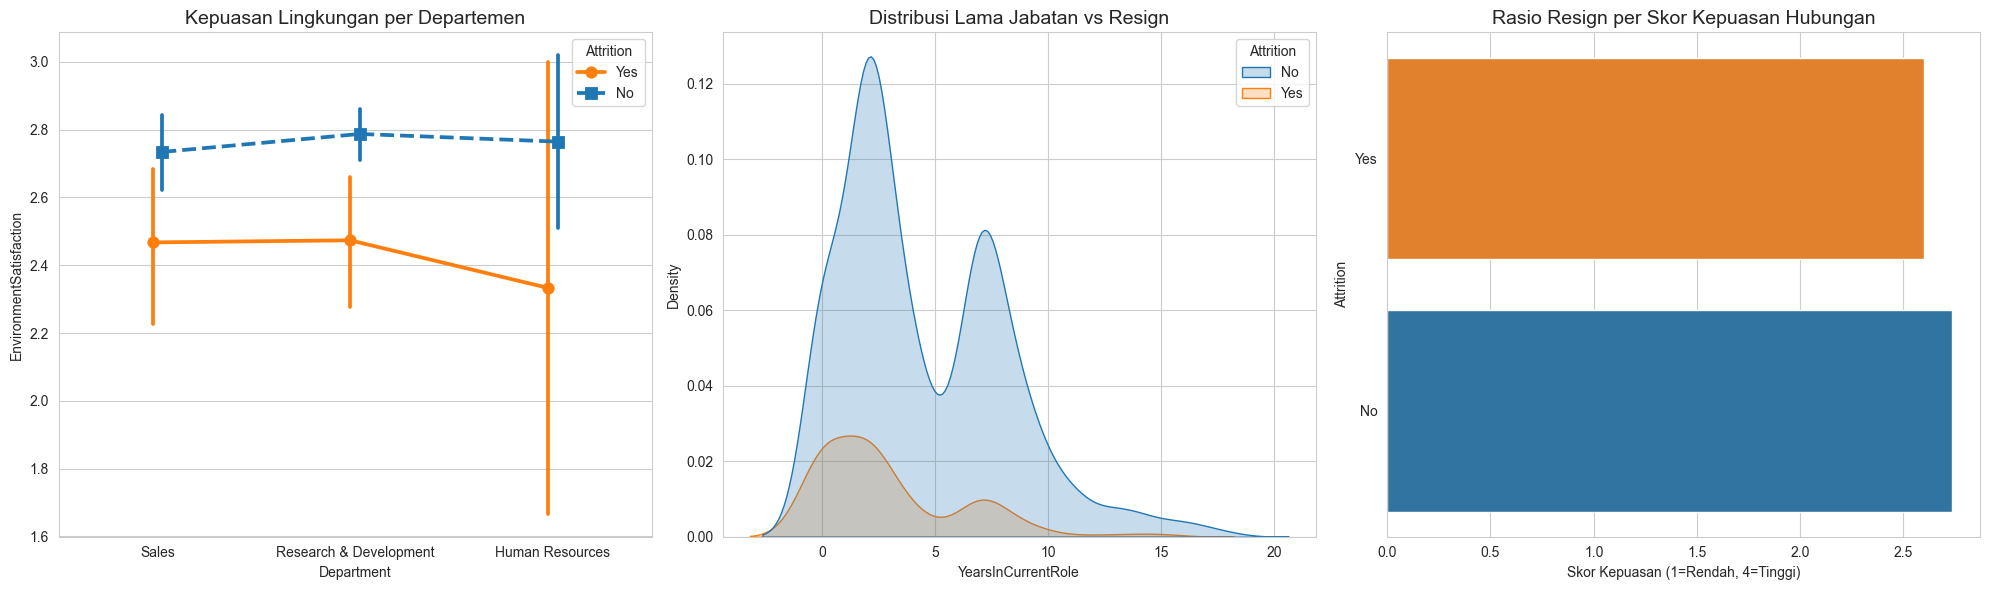

In [15]:
# Faktor tambahan yang mungkin mempengaruhi keputusan resign karyawan

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Warna
custom_palette = {'No': 'tab:blue', 'Yes': 'tab:orange'}

# 1. Lingkungan Kerja
sns.pointplot(data=df, x='Department', y='EnvironmentSatisfaction', hue='Attrition', 
              dodge=True, markers=['o', 's'], linestyles=['-', '--'], 
              palette=custom_palette, hue_order=['Yes', 'No'], ax=axes[0])
axes[0].set_title('Kepuasan Lingkungan per Departemen', fontsize=14)

# 2. Jenjang Karier
sns.kdeplot(data=df, x='YearsInCurrentRole', hue='Attrition', fill=True, 
            palette=custom_palette, hue_order=['No', 'Yes'], ax=axes[1])
axes[1].set_title('Distribusi Lama Jabatan vs Resign', fontsize=14)

# 3. Hubungan Interpersonal
sns.barplot(data=df, x='RelationshipSatisfaction', y='Attrition', 
            palette=custom_palette, order=['Yes', 'No'], ci=None, ax=axes[2])
axes[2].set_title('Rasio Resign per Skor Kepuasan Hubungan', fontsize=14)
axes[2].set_xlabel('Skor Kepuasan (1=Rendah, 4=Tinggi)')

plt.tight_layout()
plt.show()

#### Penjelasan tambahan

Selain dua pertanyaan bisnis utama, tiga faktor berikut dianalisis sebagai konteks tambahan
yang memperkaya pemahaman pola resign:

1. Kepuasan Lingkungan Kerja

Karyawan dengan kepuasan lingkungan di bawah 2.7 lebih banyak memilih resign, terutama di departemen Human Resources. Ini menunjukkan bahwa lingkungan kerja yang tidak mendukung dapat menjadi faktor signifikan dalam keputusan resign, terutama bagi karyawan yang mungkin sudah merasa kurang dihargai atau tidak nyaman di tempat kerja.

2. Lama di Jabatan Saat Ini

Karyawan yang berada di jabatan yang sama kurang dari 5 tahun cenderung lebih banyak memilih resign. Ini mengindikasikan bahwa stagnasi karier dalam jangka pendek mendorong perpindahan kerja. Karyawan yang merasa tidak ada peluang untuk berkembang atau mendapatkan tantangan baru mungkin lebih cepat memutuskan untuk mencari peluang di tempat lain.

3. Kepuasan Hubungan Antar Rekan

Faktor ini terbukti tidak terlalu dominan dalam keputusan resign. Karyawan dengan hubungan kurang baik sekalipun cenderung bertahan, kemungkinan karena pertimbangan finansial lebih besar. Namun, bagi sebagian karyawan, hubungan yang buruk bisa menjadi pemicu tambahan untuk resign jika sudah ada faktor lain seperti gaji rendah atau beban kerja tinggi.

### Analisa Lanjutan

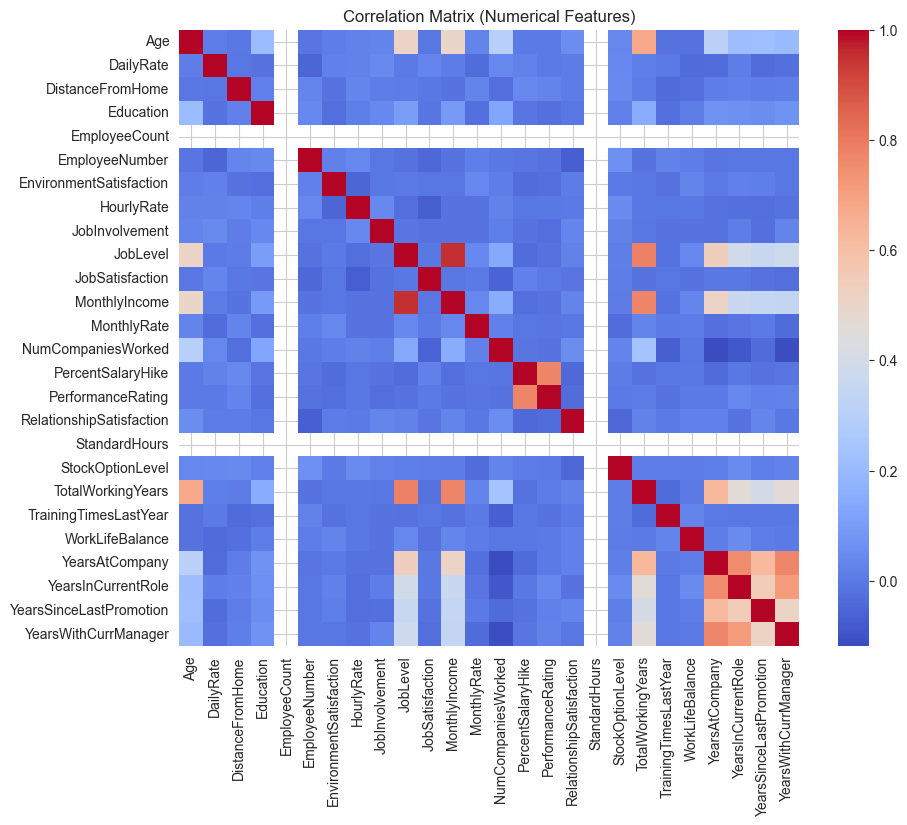

In [16]:
# Menampilkan Korelasi fitur
plt.figure(figsize=(10,8))
sns.heatmap(
    ibm_df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Matrix (Numerical Features)')
plt.show()

In [17]:
df_clean = ibm_df.copy() 

# Feature Selection
# Membuang kolom zero-variance dan ID (jika belum)
cols_to_drop_initial = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']

# Membuang kolom multikolinearitas tinggi dan redundan
cols_to_drop_corr = ['JobLevel', 'PerformanceRating', 'Department']

# Eksekusi Drop
df_clean.drop(columns=cols_to_drop_initial + cols_to_drop_corr, inplace=True, errors='ignore')

### Feature Engineering (Row-wise Transformation)

Sebelum membagi dataset, fitur-fitur turunan baru diekstraksi untuk menangkap konteks operasional HR yang tidak terlihat secara eksplisit pada data mentah. Pembuatan fitur di tahap ini dijamin **bebas dari Data Leakage** karena murni menggunakan operasi matematis baris-per-baris (*row-wise*), tanpa melibatkan agregasi atau nilai statistik populasi. 
* **StagnationIndex:** Mengukur potensi demotivasi karyawan akibat lamanya tertahan di satu posisi tanpa promosi.
* **BurnoutFlag:** Mengidentifikasi karyawan dengan risiko kelelahan tinggi (kombinasi jarak tempuh jauh dan beban lembur).
* **OverallSatisfaction & YearsPerCompany:** Indikator komposit untuk mengukur tingkat kepuasan dan kecenderungan *job-hopping*.

In [18]:
import numpy as np

# Feature Engineering
# Indeks Stagnasi (Semakin besar = makin lama nyangkut di satu posisi tanpa promosi)
df_clean['StagnationIndex'] = df_clean['YearsInCurrentRole'] - df_clean['YearsSinceLastPromotion']

# Rapor Kepuasan Keseluruhan
df_clean['OverallSatisfaction'] = (df_clean['EnvironmentSatisfaction'] + 
                                   df_clean['JobSatisfaction'] + 
                                   df_clean['RelationshipSatisfaction'])

# Burnout Flag
df_clean['BurnoutFlag'] = np.where((df_clean['OverTime'] == 'Yes') & (df_clean['DistanceFromHome'] > 10), 1, 0)

# Job Hopper Index (Rata-rata tahun per perusahaan)
df_clean['YearsPerCompany'] = np.where(df_clean['NumCompaniesWorked'] == 0, 
                                       df_clean['TotalWorkingYears'], 
                                       df_clean['TotalWorkingYears'] / df_clean['NumCompaniesWorked'])

print(f"Dimensi data setelah Feature Engineering: {df_clean.shape}")

Dimensi data setelah Feature Engineering: (1470, 32)


#### Penjelasan

1. Dilakukannya feature selection untuk membuang kolom yang tidak relevan dan menghindari multikolienaritas seperti kolom MonthlyIncome dan JobLevel yang memiliki informasi hampir indentik(korelasi di warna merah). Selain itu feature selection juga berguna untuk menghemat resource sehingga mempercepat waktu training.

2. Feature Engineering dilakukan untuk menambah kecerdasan pada data, dengan menambah beberapa fitur baru model bisa lebih baik dalam memahami data. 

3. Feature-feature baru tersebut berguna untuk memberikan insight tambahan kepada model, misalnya:
- `StagnationIndex`(`YearsInCurrentRole` - `YearsSinceLastPromotion`) untuk mengukur stagnansi karier, makin besar makin "stuck"
- `OverallSatisfaction` (Jumlah 3 skor kepuasan) untuk melihat gambaran kepuasan kerja secara keseluruhan
- `BurnoutFlag` (`OverTime`=Yes & `DistanceFromHome`>10km) untuk mengukur sinyal burnout fisik & mental
- `YearsPerCompany` (`TotalWorkingYears` / `NumCompaniesWorked`) untuk mengukur loyalitas atau kebiasaan job-hopping 

### Pemisahan Data (Train-Test Split)
Pada tahap ini, dataset dibagi menjadi data latih (training set) dan data uji (test set). Pemisahan dilakukan sebelum proses pelatihan model agar data uji tidak ikut memengaruhi proses pembelajaran, sehingga hasil evaluasi dapat menggambarkan performa model secara lebih objektif. Karena distribusi kelas pada variabel target Attrition tidak seimbang, digunakan parameter stratify untuk menjaga proporsi kelas tetap sama pada data latih maupun data uji.

In [19]:
# Split data
from sklearn.model_selection import train_test_split

# Pisahkan prediktor dan target
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

# Encode target menjadi numerik (0 dan 1)
y = y.map({'Yes': 1, 'No': 0})

# Split data (Wajib stratify agar rasio Yes/No seimbang di train dan test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_test: {X_test.shape}")

Dimensi X_train: (1176, 31)
Dimensi X_test: (294, 31)


### Penanganan Outlier (Winsorizing)

Penanganan pencilan dilakukan menggunakan metode Winsorizing berbasis IQR. Nilai yang berada di luar rentang batas bawah dan batas atas IQR dibatasi ke nilai ambang terdekat. Pendekatan ini dipilih untuk mengurangi pengaruh nilai ekstrem tanpa menghilangkan data yang ada.

In [20]:
# Penangan Outlier dengan Capping (Winsorizing) pada fitur 'MonthlyIncome'
# Hitung parameter statistik HANYA dari data latih
Q1_train = X_train['MonthlyIncome'].quantile(0.25)
Q3_train = X_train['MonthlyIncome'].quantile(0.75)
IQR_train = Q3_train - Q1_train

lower_bound = Q1_train - 1.5 * IQR_train
upper_bound = Q3_train + 1.5 * IQR_train

# Aplikasikan batasan data latih ke KEDUA subset data (Train & Test)
X_train['MonthlyIncome'] = X_train['MonthlyIncome'].clip(lower_bound, upper_bound)
X_test['MonthlyIncome'] = X_test['MonthlyIncome'].clip(lower_bound, upper_bound)

print("Outlier pada MonthlyIncome berhasil di-capping berdasarkan distribusi X_train.")

Outlier pada MonthlyIncome berhasil di-capping berdasarkan distribusi X_train.


### Categorical Encoding (One-Hot Encoding)

Variabel kategorikal diubah ke bentuk numerik menggunakan One-Hot Encoding agar dapat diproses oleh algoritma machine learning. Metode ini menghasilkan representasi biner untuk setiap kategori tanpa mengasumsikan adanya hubungan urutan antar kategori. Untuk mengurangi risiko multikolinearitas, digunakan parameter drop_first=True pada proses pembentukan variabel dummy.

In [21]:
# One-Hot Encoding untuk fitur kategorikal
# Ambil daftar kolom kategorikal
cat_cols = X_train.select_dtypes(include=['object']).columns

# Terapkan One-Hot Encoding (drop_first=True untuk menghindari jebakan multikolinearitas)
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Pastikan urutan dan jumlah kolom persis sama antara train dan test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Dimensi X_train setelah encoding: {X_train.shape}")

Dimensi X_train setelah encoding: (1176, 44)


### Standardisasi Skala Fitur (Feature Scaling)

Standardisasi dilakukan menggunakan StandardScaler untuk menyamakan skala antar fitur yang memiliki rentang nilai berbeda. Proses ini membantu algoritma machine learning bekerja lebih optimal, terutama pada model yang sensitif terhadap perbedaan skala data. Nilai rata-rata dan standar deviasi dihitung dari data latih, lalu diterapkan pada data latih dan data uji.

In [22]:
# Standardisasi 
from sklearn.preprocessing import StandardScaler

# Inisialisasi Scaler
scaler = StandardScaler()

# Fit & Transform HANYA pada X_train
X_train_scaled = scaler.fit_transform(X_train)

# TRANSFORM PASIF pada X_test (TIDAK BOLEH pakai fit_transform)
X_test_scaled = scaler.transform(X_test) 

# Kembalikan tipe data ke DataFrame agar nama kolom bisa dibaca
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Standardisasi selesai.")

Standardisasi selesai.


### Penanganan Ketidakseimbangan Kelas (SMOTE)

Ketidakseimbangan kelas pada variabel Attrition ditangani menggunakan metode SMOTE. Teknik ini menghasilkan sampel sintetis pada kelas minoritas sehingga distribusi kelas pada data latih menjadi lebih seimbang. SMOTE hanya diterapkan pada data latih, sedangkan data uji tetap dipertahankan dalam kondisi aslinya untuk menjaga objektivitas proses evaluasi model.

In [23]:
# Smote untuk menangani ketidakseimbangan kelas pada data
from imblearn.over_sampling import SMOTE

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Resample hanya pada data latih
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Proporsi Target SEBELUM SMOTE (Data Latih)")
print(y_train.value_counts(normalize=True))

print("\nProporsi Target SESUDAH SMOTE (Data Latih)")
print(y_train_smote.value_counts(normalize=True))

print(f"\nDimensi akhir X_train_smote (siap modeling): {X_train_smote.shape}")
print(f"Dimensi akhir X_test_scaled (siap pengujian): {X_test_scaled.shape}")

Proporsi Target SEBELUM SMOTE (Data Latih)
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Proporsi Target SESUDAH SMOTE (Data Latih)
Attrition
0    0.5
1    0.5
Name: proportion, dtype: float64

Dimensi akhir X_train_smote (siap modeling): (1972, 44)
Dimensi akhir X_test_scaled (siap pengujian): (294, 44)


In [24]:
# Menyatukan fitur dan target latih (Data hasil SMOTE sudah otomatis reset index)
train_df = X_train_smote.copy()
train_df['Attrition'] = y_train_smote

# Menyatukan fitur dan target uji (Wajib reset index agar TIDAK JADI NaN)
test_df = X_test_scaled.copy()
test_df.reset_index(drop=True, inplace=True) 

# Reset juga index y_test sebelum digabung
y_test_clean = y_test.reset_index(drop=True)
test_df['Attrition'] = y_test_clean

# Menggabungkan Train dan Test menjadi satu file tunggal
df_final_ml_ready = pd.concat([train_df, test_df], axis=0, ignore_index=True)

# Ekspor
df_final_ml_ready.to_csv('Dataset/IBM_HR_Cleaned.csv', index=False)

print(f"Dimensi dataset final: {df_final_ml_ready.shape}")
print(f"Jumlah nilai kosong pada target Attrition: {df_final_ml_ready['Attrition'].isna().sum()}")

Dimensi dataset final: (2266, 45)
Jumlah nilai kosong pada target Attrition: 0


# Kesimpulan Akhir

Berdasarkan proses Data Wrangling, EDA, Feature Engineering, dan Data Preparation pada dataset IBM HR Attrition (1.470 karyawan), ditemukan bahwa kualitas data sangat baik tanpa missing value maupun duplikasi data. Dataset memiliki ketidakseimbangan kelas (83,88% bertahan dan 16,12% resign) yang berhasil ditangani menggunakan SMOTE sehingga distribusi data latih menjadi seimbang (50:50). Selain itu, metode Winsorizing berhasil mengurangi pengaruh outlier pada beberapa variabel numerik.

Hasil analisis menunjukkan bahwa faktor OverTime memiliki hubungan kuat dengan attrition, di mana karyawan yang bekerja lembur memiliki tingkat attrition sebesar 30,53%, jauh lebih tinggi dibandingkan karyawan tanpa lembur (10,44%). Analisis kohort juga menunjukkan bahwa kelompok gaji rendah dan masa kerja singkat memiliki risiko attrition tertinggi (28,85%), sedangkan kelompok gaji tinggi dan masa kerja lama memiliki risiko terendah (9,57%). Temuan ini mengindikasikan bahwa retensi karyawan dipengaruhi oleh kombinasi faktor kompensasi, masa kerja, dan kondisi kerja.
